# 03 — Model-level null patterns

Test whether missingness patterns are concentrated within SSD model populations without assuming one-to-one pattern/model identity.

In [1]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPORT_DIR = Path("../exports")
assert EXPORT_DIR.exists(), f"Expected exports directory at {EXPORT_DIR.resolve()}"

def load_csv(name):
    path = EXPORT_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing required export: {path}")
    return pd.read_csv(path)

def drop_export_index(df):
    return df.drop(columns=[c for c in df.columns if c.startswith("Unnamed:")], errors="ignore")

def attr_id(variable):
    return int(str(variable).split("_")[-1])

def canonical_pattern(serialized):
    return tuple(sorted(json.loads(serialized)))

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 100)


In [2]:
m18=load_csv("smart_2018_model_null_patterns.csv")
m19=load_csv("smart_2019_model_null_patterns.csv")
for year,d in [(2018,m18),(2019,m19)]:
    top=d.loc[d.PATTERN_RANK.eq(1), ["MODEL_CODE","ROW_COUNT","MODEL_ROWS","MODEL_PERCENT","MODEL_SHARE_OF_PATTERN"]].copy()
    print(f"\n{year} leading pattern per model")
    display(top.sort_values("MODEL_CODE"))


2018 leading pattern per model


,MODEL_CODE,ROW_COUNT,MODEL_ROWS,MODEL_PERCENT,MODEL_SHARE_OF_PATTERN
0,MA1,8865627,12173806,72.825434,100.000000
10,MA2,38428792,38660076,99.401750,100.000000
20,MB1,12205270,12240078,99.715623,100.000000
30,MB2,15665147,15713902,99.689733,100.000000
40,MC1,53660875,53789530,99.760818,94.263974
50,MC2,3265300,3266271,99.970272,5.736026



2019 leading pattern per model


,MODEL_CODE,ROW_COUNT,MODEL_ROWS,MODEL_PERCENT,MODEL_SHARE_OF_PATTERN
0,MA1,6168476,8451862,72.983634,100.000000
10,MA2,30733487,30738892,99.982416,100.000000
20,MB1,14018264,14021140,99.979488,100.000000
30,MB2,15291844,15294810,99.980608,99.999987
40,MC1,61469043,61484596,99.974704,89.745159
50,MC2,7023836,7277321,96.516781,10.254841


## Compare leading-pattern concentration

,2018,2019
MODEL_CODE,,
MA1,72.825434,72.983634
MA2,99.401750,99.982416
MB1,99.715623,99.979488
MB2,99.689733,99.980608
MC1,99.760818,99.974704
MC2,99.970272,96.516781


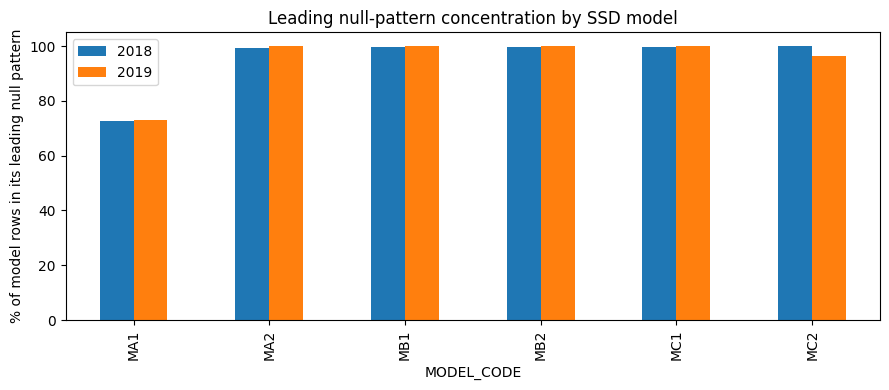

In [3]:
top18=m18.loc[m18.PATTERN_RANK.eq(1),["MODEL_CODE","MODEL_PERCENT"]].set_index("MODEL_CODE").rename(columns={"MODEL_PERCENT":"2018"})
top19=m19.loc[m19.PATTERN_RANK.eq(1),["MODEL_CODE","MODEL_PERCENT"]].set_index("MODEL_CODE").rename(columns={"MODEL_PERCENT":"2019"})
comp=top18.join(top19).sort_index()
display(comp)
comp.plot(kind="bar", figsize=(9,4))
plt.ylabel("% of model rows in its leading null pattern")
plt.ylim(0,105)
plt.title("Leading null-pattern concentration by SSD model")
plt.tight_layout(); plt.show()

## Check whether a leading pattern is unique to one model

In [4]:
for year,d in [(2018,m18),(2019,m19)]:
    mc1=d[(d.MODEL_CODE=="MC1") & (d.PATTERN_RANK==1)].iloc[0]
    pid=mc1.NULL_PATTERN_ID
    shares=d[d.NULL_PATTERN_ID==pid][["MODEL_CODE","ROW_COUNT","MODEL_SHARE_OF_PATTERN"]].sort_values("ROW_COUNT",ascending=False)
    print(f"\n{year} models contributing to MC1's dominant pattern {pid[:12]}…")
    display(shares)


2018 models contributing to MC1's dominant pattern d237e8c2e240…


,MODEL_CODE,ROW_COUNT,MODEL_SHARE_OF_PATTERN
40,MC1,53660875,94.263974
50,MC2,3265300,5.736026



2019 models contributing to MC1's dominant pattern d237e8c2e240…


,MODEL_CODE,ROW_COUNT,MODEL_SHARE_OF_PATTERN
40,MC1,61469043,89.745159
50,MC2,7023836,10.254841


**Interpretation.** The high within-model concentration supports a structural/schema interpretation, but shared patterns—especially between MC1 and MC2—show that pattern ID is not a unique model identifier.